In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
HW_data = pd.read_excel("H and W (ML) Data.xlsx", index_col=0)
HW_data

,Name,Roll No.,Height (in cm),Weight (in kg)
Sr. No.,,,,
1,Vishal Baghel,1,170.00,70.00
2,Gautam Chauhan,4,173.00,85.00
3,Mohit Dadwani,5,172.00,53.00
4,Etiko Solih,7,180.00,65.00
5,Aatreyee,13,175.00,80.00
6,Aasima,18,167.64,55.00
7,Panchal dhruvi,22,164.00,62.00
8,Jay Panchal,23,180.00,70.00
9,Kaushal Jayeshbhai Panchal,24,183.00,60.00


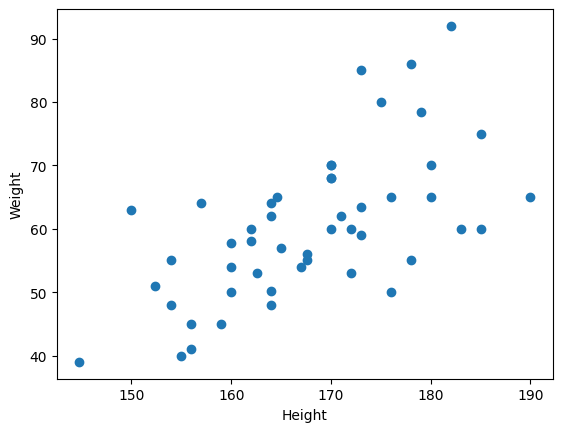

In [3]:
# sns.lineplot()
heights = HW_data["Height (in cm)"]
weights = HW_data["Weight (in kg)"]
plt.scatter(heights, weights)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()

In [4]:
weights.min()

39.0

In [5]:
n = len(heights)
n

49

In [11]:
def simple_lr_scratch(x, y):
    n = len(x)
    
    # Formulas for b (slope) and a (intercept) [cite: 30]
    a1 = (n * np.sum(x*y) - np.sum(x)*np.sum(y)) / (n * np.sum(x**2) - np.sum(x)**2)
    a0 = np.mean(y) - a1 * np.mean(x)
    return a0, a1

In [12]:
a0, a1 = simple_lr_scratch(heights, weights)

In [14]:
def y_predict(x):
    return a0 + (a1*x)

In [17]:
HW_data['w_pred'] = pd.Series([y_predict(a) for a in heights])

In [18]:
HW_data.head()

,Name,Roll No.,Height (in cm),Weight (in kg),w_pred
Sr. No.,,,,,
1,Vishal Baghel,1,170.0,70.0,63.997860
2,Gautam Chauhan,4,173.0,85.0,63.283762
3,Mohit Dadwani,5,172.0,53.0,68.996541
4,Etiko Solih,7,180.0,65.0,65.426054
5,Aatreyee,13,175.0,80.0,60.170298


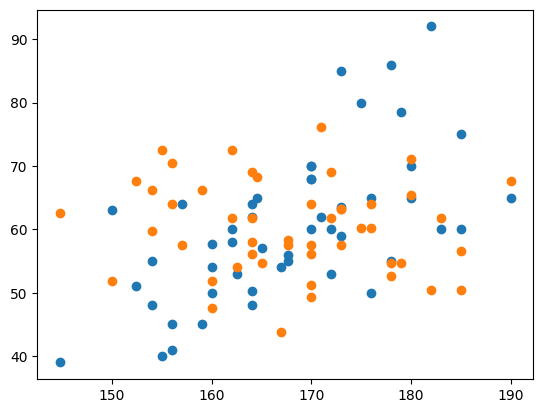

In [20]:
plt.scatter(heights, weights)
plt.scatter(heights, HW_data['w_pred'])
plt.show()

--- Model Outcomes ---
Equation: Weight = -59.54 + 0.71 * Height
R-Squared: 0.3891
SSE: 3954.67 | MSE: 80.71 | RMSE: 8.98
MAE: 7.25 | MAPE: 12.05%


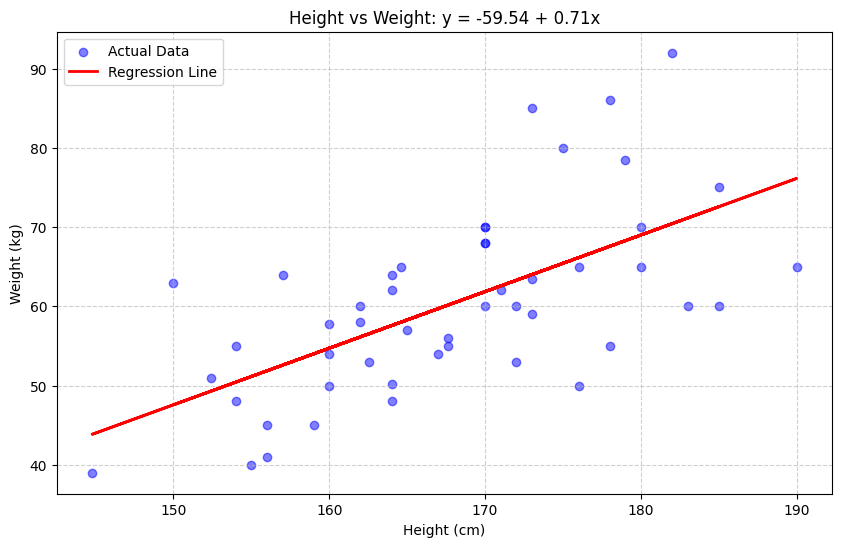

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Load Data
# Assuming the Excel has columns 'Height (in cm)' and 'Weight (in kg)'
HW = pd.read_excel("H and W (ML) Data.xlsx", index_col=0)

# FIX: Correct way to rename/assign columns
HW_data = pd.DataFrame()
HW_data['heights'] = HW['Height (in cm)']
HW_data['weights'] = HW['Weight (in kg)']

heights = HW_data['heights'].values
weights = HW_data['weights'].values

# 2. Simple Linear Regression from Scratch (Least Squares)
def simple_lr_scratch(x, y):
    n = len(x)
    sum_x, sum_y = np.sum(x), np.sum(y)
    sum_xx, sum_xy = np.sum(x**2), np.sum(x*y)
    
    # Formula for a1 (Slope) and a0 (Intercept)
    a1 = (n * sum_xy - sum_x * sum_y) / (n * sum_xx - sum_x**2)
    a0 = (sum_y - a1 * sum_x) / n
    return a0, a1

a0, a1 = simple_lr_scratch(heights, weights)

# 3. Prediction (Vectorized)
# FIX: Use 'heights' because that is what we named the column above
HW_data['w_pred'] = a0 + (a1 * HW_data['heights'])

# 4. Comprehensive Evaluation Metrics (Scratch)
y_actual = weights
y_pred = HW_data['w_pred'].values
n = len(y_actual)

# Sum of Squares
sse = np.sum((y_actual - y_pred)**2)          # Sum of Squared Errors
ssr = np.sum((y_pred - np.mean(y_actual))**2) # Sum of Squares Regression
sst = np.sum((y_actual - np.mean(y_actual))**2) # Total Sum of Squares

# Accuracy Metrics
r2 = 1 - (sse / sst)
mae = np.mean(np.abs(y_actual - y_pred))
mse = sse / n
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100

print(f"--- Model Outcomes ---")
print(f"Equation: Weight = {a0:.2f} + {a1:.2f} * Height")
print(f"R-Squared: {r2:.4f}")
print(f"SSE: {sse:.2f} | MSE: {mse:.2f} | RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f} | MAPE: {mape:.2f}%")

# 5. Outcome Determination Plot
plt.figure(figsize=(10, 6))
plt.scatter(heights, weights, color='blue', alpha=0.5, label='Actual Data')
plt.plot(heights, HW_data['w_pred'], color='red', linewidth=2, label='Regression Line')
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title(f"Height vs Weight: y = {a0:.2f} + {a1:.2f}x")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()